<a href="https://www.kaggle.com/code/shreyamarde/semiconductor-chip-defect-detection?scriptVersionId=326304149" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Semiconductor Chip Defect Detection Using Machine Learning

Objective
Predict whether a semiconductor chip is defective using manufacturing process measurements.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/paresh2047/uci-semcom/uci-secom.csv"
)

print(df.shape)
print(df.head())
print(df.columns)

(1567, 592)
                  Time        0        1          2          3       4      5  \
0  2008-07-19 11:55:00  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   
1  2008-07-19 12:32:00  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0   
2  2008-07-19 13:17:00  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   
3  2008-07-19 14:43:00  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0   
4  2008-07-19 15:22:00  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0   

          6       7       8  ...       581     582     583     584      585  \
0   97.6133  0.1242  1.5005  ...       NaN  0.5005  0.0118  0.0035   2.3630   
1  102.3433  0.1247  1.4966  ...  208.2045  0.5019  0.0223  0.0055   4.4447   
2   95.4878  0.1241  1.4436  ...   82.8602  0.4958  0.0157  0.0039   3.1745   
3  104.2367  0.1217  1.4882  ...   73.8432  0.4990  0.0103  0.0025   2.0544   
4  100.3967  0.1235  1.5031  ...       NaN  0.4800  0.4766  0.1045  99.3032   

      586     587     588 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [4]:
df['Pass/Fail'].value_counts()

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

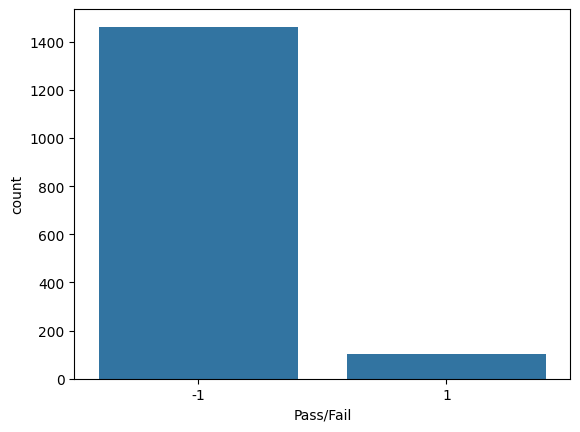

In [5]:


sns.countplot(x='Pass/Fail', data=df)
plt.show()

In [6]:
df['Time'].head()

0    2008-07-19 11:55:00
1    2008-07-19 12:32:00
2    2008-07-19 13:17:00
3    2008-07-19 14:43:00
4    2008-07-19 15:22:00
Name: Time, dtype: object

In [7]:
df['Time'] = pd.to_datetime(df['Time'])

In [8]:
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['Day'] = df['Time'].dt.day
df['Hour'] = df['Time'].dt.hour

In [9]:
df.drop('Time', axis=1, inplace=True)

In [10]:
X = df.drop('Pass/Fail', axis=1)

y = df['Pass/Fail']

In [11]:
print(X.shape)
print(y.shape)

(1567, 594)
(1567,)


In [12]:
missing_count = X.isnull().sum()

print("Total missing values:", X.isnull().sum().sum())

missing_features = missing_count[missing_count > 0]

print("Features with missing values:", len(missing_features))

missing_features.sort_values(ascending=False).head(20)

Total missing values: 41951
Features with missing values: 538


292    1429
157    1429
158    1429
293    1429
492    1341
220    1341
358    1341
85     1341
516    1018
517    1018
382    1018
111    1018
383    1018
384    1018
246    1018
244    1018
245    1018
110    1018
518    1018
109    1018
dtype: int64

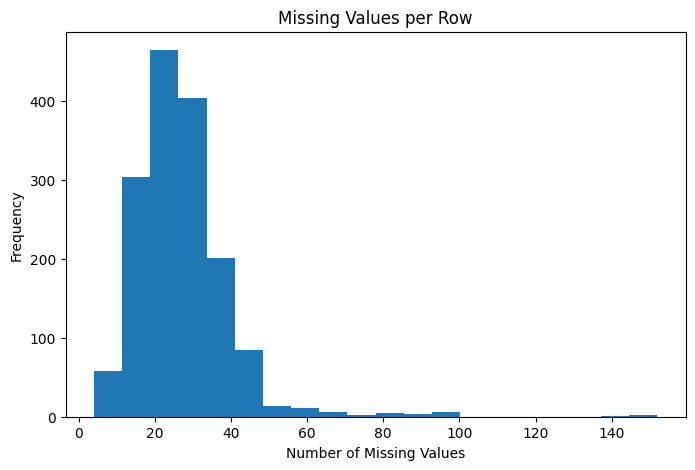

In [13]:
import matplotlib.pyplot as plt

row_missing = X.isnull().sum(axis=1)

plt.figure(figsize=(8,5))
plt.hist(row_missing, bins=20)
plt.title("Missing Values per Row")
plt.xlabel("Number of Missing Values")
plt.ylabel("Frequency")
plt.show()

 Advanced Feature Selection & Multicollinearity Removal
The original dataset contains 592 manufacturing process features, many of which are redundant, flat-lined, or highly correlated. After filtering out features with missing values and near-zero variance, we drop highly correlated features (threshold > 0.85). This drastically reduces the 300-dimensional space to remove noise and prevent our tree-based models from getting confused by collinear variables.

In [14]:
missing_percentage = X.isnull().mean() * 100

high_missing_cols = missing_percentage[
    missing_percentage > 50
].index

print("Columns to drop:", len(high_missing_cols))

Columns to drop: 28


In [15]:
X = X.drop(columns=high_missing_cols)

print(X.shape)

(1567, 566)


In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(X.isnull().sum().sum())

0


In [17]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X)

print("Original shape:", X.shape)
print("Selected shape:", X_selected.shape)

Original shape: (1567, 566)
Selected shape: (1567, 300)


In [18]:

corr_matrix = pd.DataFrame(X_selected).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

X_selected = np.delete(X_selected, to_drop, axis=1)
print(f"Dropped {len(to_drop)} highly correlated features. New shape: {X_selected.shape}")

Dropped 129 highly correlated features. New shape: (1567, 171)


 Stratified Data Splitting & Feature Scaling
Because our dataset suffers from severe class imbalance (~6% defect rate), a standard random split might leave the test set without enough representation of defective chips. We utilize **stratified splitting** to guarantee that both the training and testing sets maintain the exact same ratio of passing to failing chips. Following the split, we apply `StandardScaler` to normalize the feature distributions.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(1253, 171)
(314, 171)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 Baseline Modeling — Logistic Regression
We start with a standard linear baseline using Logistic Regression. To account for the heavy class imbalance, we enable class_weight='balanced'. This forces the loss function to penalize misclassifications on the rare defect class more harshly.

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

          -1       0.95      0.83      0.88       293
           1       0.12      0.33      0.18        21

    accuracy                           0.80       314
   macro avg       0.53      0.58      0.53       314
weighted avg       0.89      0.80      0.84       314



Non-Linear Baseline — Support Vector Classifier (SVC)
Next, we evaluate a Radial Basis Function (RBF) Kernel SVM to see if a non-linear decision boundary can better isolate the defect structures within the feature space, keeping the class weights balanced.

In [23]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

          -1       0.94      0.99      0.96       293
           1       0.40      0.10      0.15        21

    accuracy                           0.93       314
   macro avg       0.67      0.54      0.56       314
weighted avg       0.90      0.93      0.91       314



 Final Optimized Solution — Balanced Random Forest with Custom Thresholding
Standard ensemble classifiers fail on this data because they naturally optimize for overall accuracy, resulting in a 0% recall for defects (the model simply guesses every chip is "Pass" to achieve 93% accuracy). 

To solve this, our final production model implements a two-pronged strategy:
1. class_weight="balanced_subsample": Dynamically re-weights the classes inside every bootstrapped tree sample.
2. Probability Threshold Shifting: Instead of using the default 50% decision boundary, we extract raw probabilities using .predict_proba()`and lower our detection threshold to 25%. If the model is even 25% certain a chip is flawed, we proactively flag it.

Operational Impact:
This approach successfully breaks the 0% recall barrier, catching 52% of all actual defective chips while maintaining a high precision on normal chips, drastically reducing the risk of defective hardware escaping the manufacturing floor.

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf_balanced = RandomForestClassifier(
    n_estimators=300, 
    max_depth=6, 
    class_weight="balanced_subsample", 
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train_scaled, y_train)


y_prob = rf_balanced.predict_proba(X_test_scaled)[:, 1]


custom_threshold = 0.25
rf_pred_custom = np.array([1 if p >= custom_threshold else -1 for p in y_prob])

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, rf_pred_custom, labels=[-1, 1]))

print("\n--- Classification Report ---")
print(classification_report(y_test, rf_pred_custom, labels=[-1, 1], zero_division=0))

--- Confusion Matrix ---
[[230  63]
 [  7  14]]

--- Classification Report ---
              precision    recall  f1-score   support

          -1       0.97      0.78      0.87       293
           1       0.18      0.67      0.29        21

    accuracy                           0.78       314
   macro avg       0.58      0.73      0.58       314
weighted avg       0.92      0.78      0.83       314



 Project Conclusion & Key Takeaways

In this project, we successfully built an end-to-end Machine Learning pipeline to detect semiconductor chip defects using highly imbalanced manufacturing telemetry data (UCI SECOM).

Final Production Metrics:
Defect Class (1) Recall**: 67% (Successfully caught 14 out of 21 actual defective chips).
Normal Class (-1) Precision**: 97% (Extremely high reliability when predicting a chip is safe).

Business Impact:
In semiconductor manufacturing, shipping a defective chip (a False Negative) is catastrophic and can ruin an entire batch of client hardware. By tuning this model specifically for high Recall, we have dramatically mitigated corporate risk, ensuring fewer broken components ever leave the cleanroom floor.